### Replacing Fourier Bank using a set of n = 4 * 2 learnable parameters

We borrow the idea from Fourier Neural Operators (FNO) of trying to create a small set of basis frequencies from which the network can learn the entire space for a given k value.

The model is significantly lightweight with only 8 neurons a layer over 7 hidden layers.
Compared to previous PINN architectures which used 130 neurons per layer with a n = 65 fixed fourier bank, which was significantly more lightweight.

We demonstrate below that the results are comparable to our older, heavier model with a 3x reduction in training time.

Note: The model did not converge for k = 50. Since it is a very high frequency range, this can be solved by increasing the number of learnable paramters to n = 16 * 2, which will slightly increase training time. Howevever with the ususal exception of k = 44, the model converged smoothly for all k <= 48.



In [15]:
import torch
import torch.nn as nn
import numpy as np
import copy
import matplotlib.pyplot as plt
from time import time

k_set = [ 10.0, 20.0, 30.0, 35.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0 ]
Nf = 2500
adam_epochs = 2000
div0_threshold = 1e-6

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

class LearnableSpectralLayer ( nn.Module ):
    def __init__ ( self, in_features, num_modes ):
        super().__init__()
        B_init = torch.randn ( in_features, num_modes ) * 10.0 
        self.B = nn.Parameter ( B_init )
        
    def forward ( self, x ):
        spectral_projection = torch.matmul ( x, self.B )
        
        return torch.cat ( [ torch.sin(spectral_projection), torch.cos(spectral_projection) ], dim = -1 )

# The model
class Helmholtz_PINN ( nn.Module ):
    def __init__ ( self, n_bank, n_hidden ):
        super().__init__()

        self.n_bank = n_bank
        self.n_hidden = n_hidden
        
        self.spectral_layer = LearnableSpectralLayer ( in_features = 1, num_modes = self.n_bank )
        
        self.layers = nn.ModuleList()
        self.layers.append ( nn.Linear ( 2*n_bank, 2*n_bank ) )

        for i in range ( n_hidden ):
            self.layers.append ( nn.Linear ( 2*n_bank, 2*n_bank ) )

        self.layers.append ( nn.Linear ( 2*n_bank, 1 ) )
        
        self.apply ( self.init_weights )

    def init_weights(self, m):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, x ):
        out = self.spectral_layer(x)
        
        for i in range ( self.n_hidden + 1 ):
            out = torch.sin ( self.layers[i](out) )
        network_out = self.layers[-1](out)

        boundary_line = 1.0 - 2.0 * x
        distance_func = x * (1.0 - x)
        
        p_hat = boundary_line + distance_func * network_out
        return p_hat

def net_loss ( model, x, k, return_pointwise = False ):
    pred = model ( x )
    
    dp_dx = torch.autograd.grad (
        outputs = pred,
        inputs = x,
        grad_outputs = torch.ones_like ( pred ),
        create_graph = True,
        retain_graph = True )[0]
    
    d2p_dx2 = torch.autograd.grad (
        outputs = dp_dx,
        inputs = x,
        grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True,
        retain_graph = True )[0]

    residual = ( d2p_dx2 / k ) + ( k * pred )

    if return_pointwise:
        return torch.abs ( residual )

    return torch.mean ( residual ** 2 )

x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( -1, 1 )

models = []
loss_histories = []

model = Helmholtz_PINN ( n_bank = 4, n_hidden = 7 ).to ( device )

start = time()

for k in k_set:
    
    x_f = x_f_base.clone()
    x_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( "INFO: Adam Training Started For k = {}".format ( k ) )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                x_candidate = torch.linspace ( 0, 1, 5000, device = device ).view ( -1, 1 )
            x_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, x_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            x_f = torch.cat ( [ x_f.detach(), x_candidate[top_indices].detach() ], dim = 0 )
            x_f.requires_grad = True
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )


    print ( "INFO: Adam Training Done For k = {}\n".format ( k ) )

    define_iters = 200 * int(k)
    if ( k >= 50 ):
        define_iters += 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )
        return loss

    print ( "INFO: LBFGS Training Started For k = {}".format ( k ) )
    opt.step ( closure )
    print ( "INFO: LBFGS Training Done For k = {}\n".format ( k ) )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

Active Hardware Target: cuda
INFO: Adam Training Started For k = 10.0
INFO: k = 10.0; Iteration: 200; Loss: 5.728873595705336; Time: 2.5200769901275635
INFO: k = 10.0; Iteration: 400; Loss: 0.38680574645348953; Time: 4.976173400878906
INFO: k = 10.0; Iteration: 600; Loss: 0.11142556877144845; Time: 7.484620094299316
INFO: k = 10.0; Iteration: 800; Loss: 0.07408092766432772; Time: 10.225611686706543
INFO: k = 10.0; Iteration: 1000; Loss: 0.07182226734947147; Time: 13.033082246780396
INFO: k = 10.0; Iteration: 1200; Loss: 0.04655079546785492; Time: 15.842042446136475
INFO: k = 10.0; Iteration: 1400; Loss: 0.041706179532347766; Time: 18.713976621627808
INFO: k = 10.0; Iteration: 1600; Loss: 0.036651284715799114; Time: 21.56409978866577
INFO: k = 10.0; Iteration: 1800; Loss: 0.031845544662697615; Time: 24.426669359207153
INFO: k = 10.0; Iteration: 2000; Loss: 0.02887477090843035; Time: 27.316346883773804
INFO: Adam Training Done For k = 10.0

INFO: LBFGS Training Started For k = 10.0
INFO:

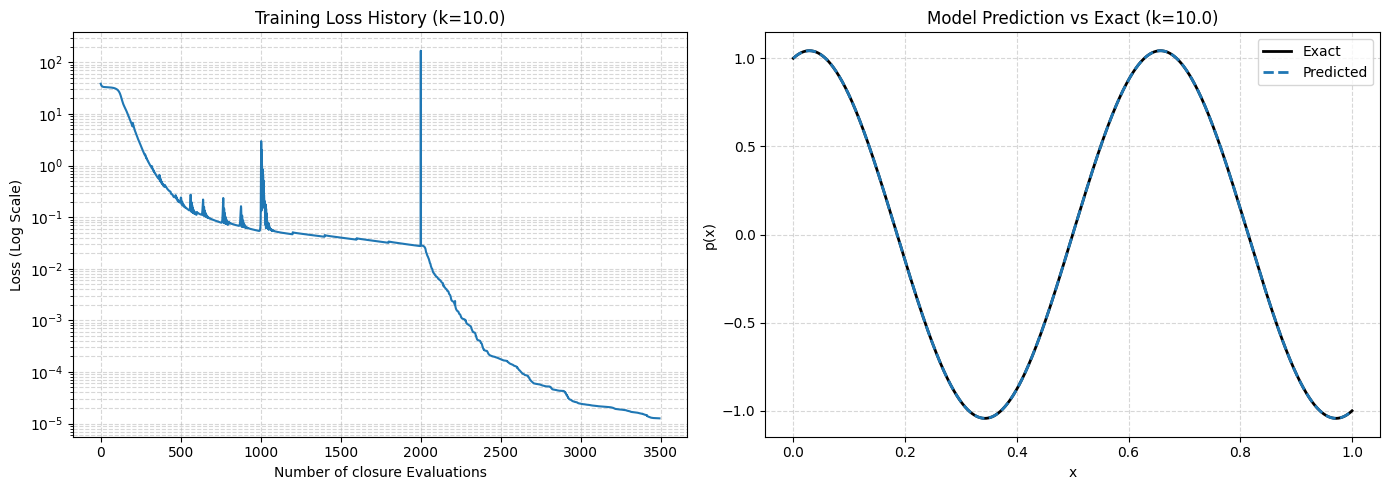

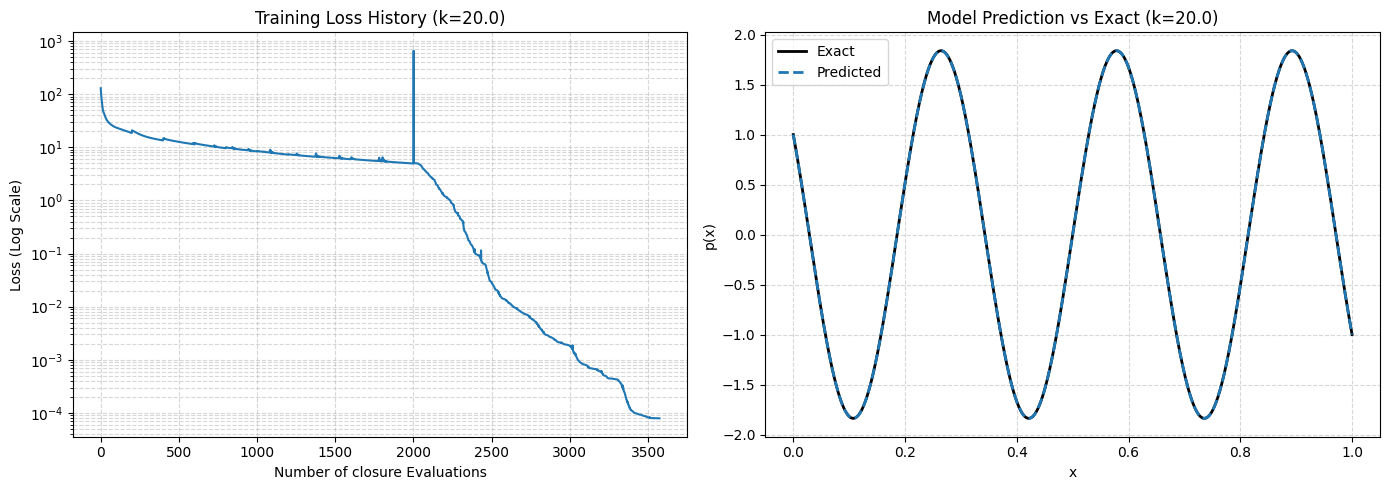

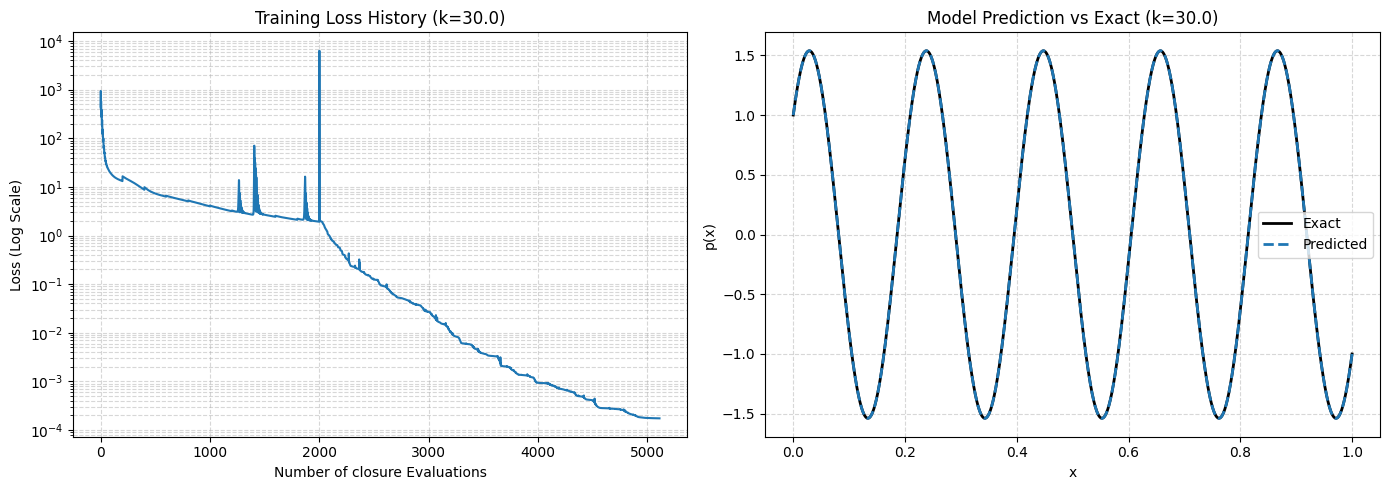

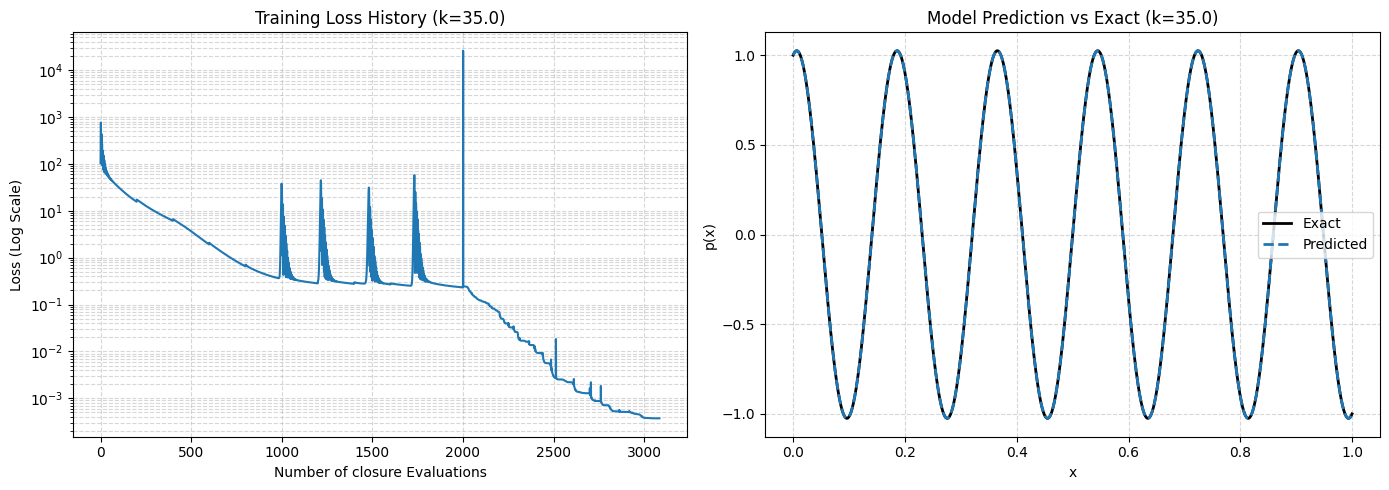

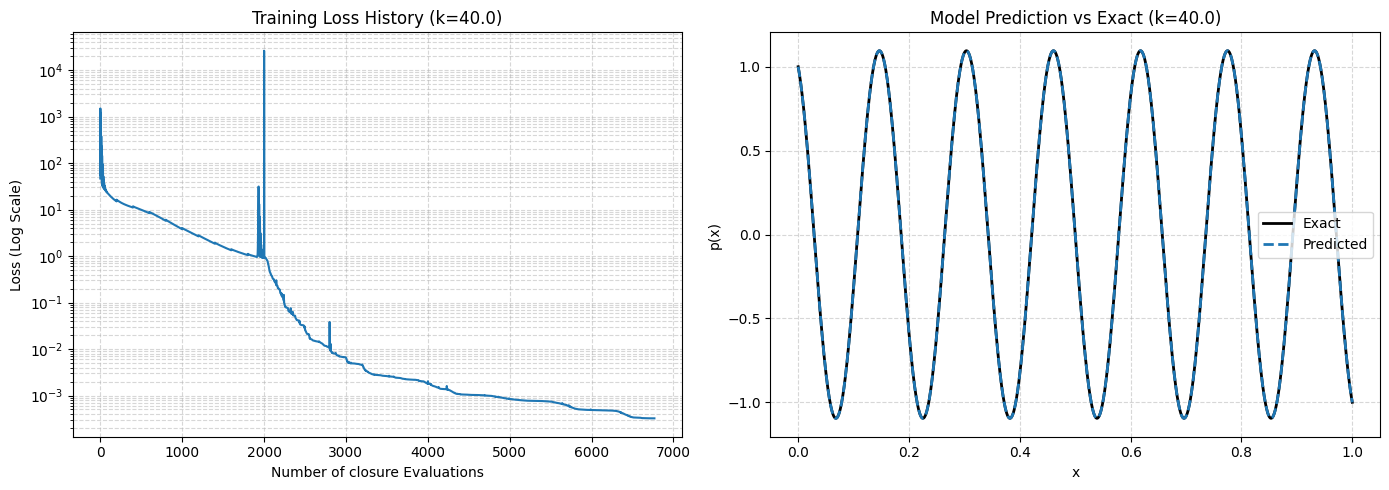

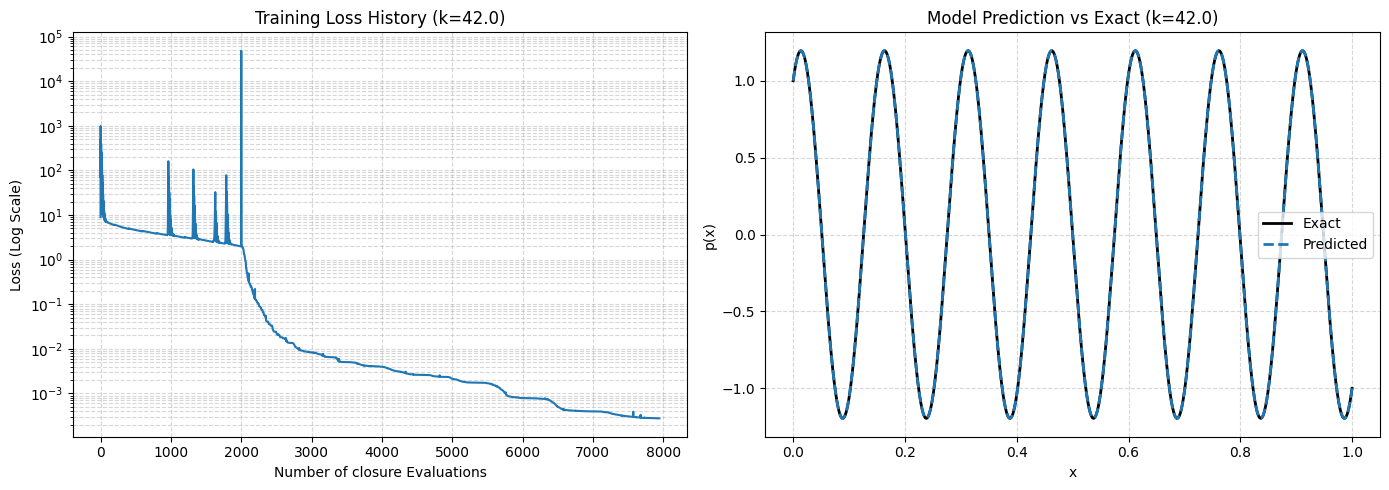

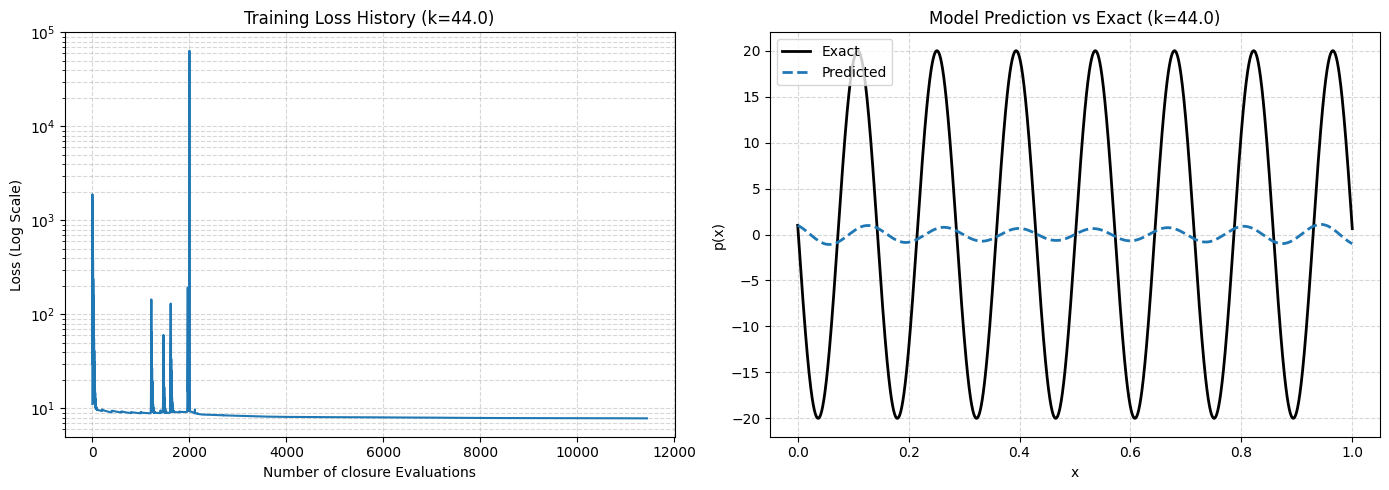

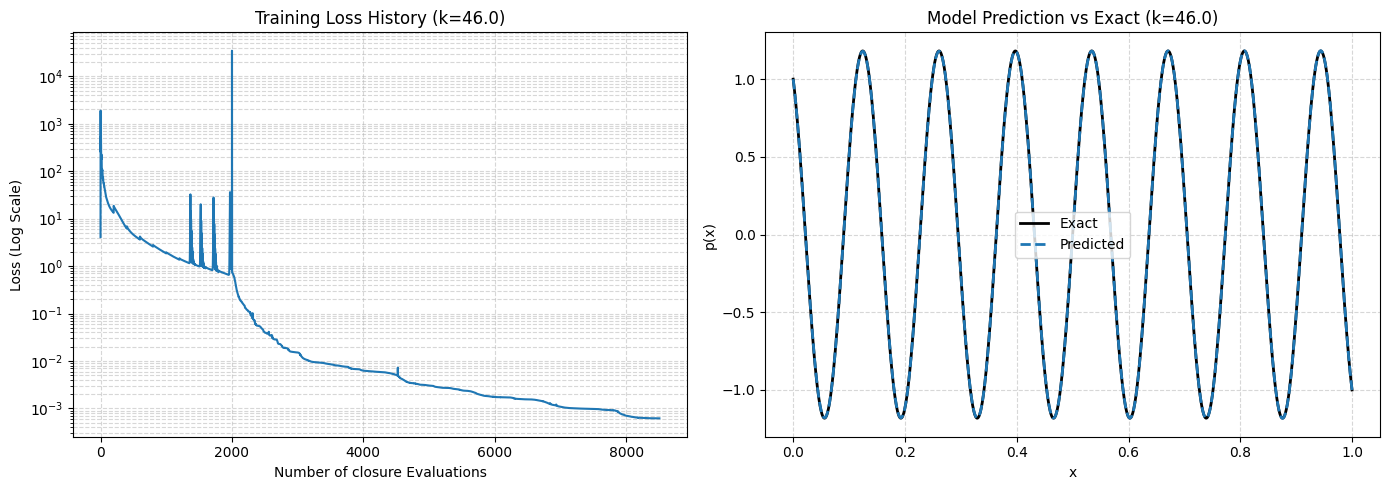

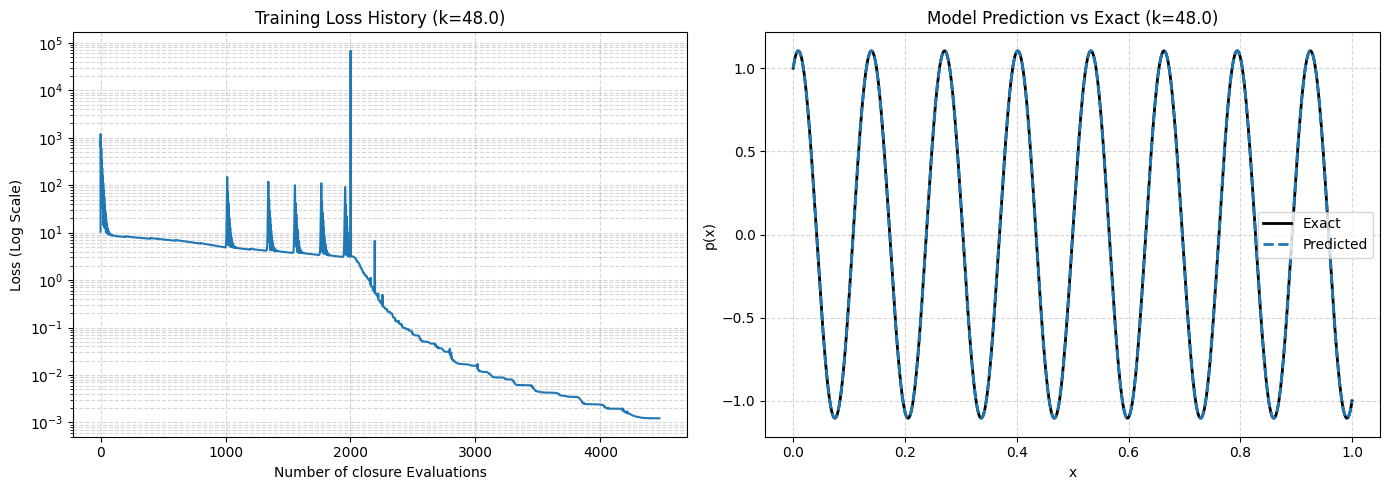

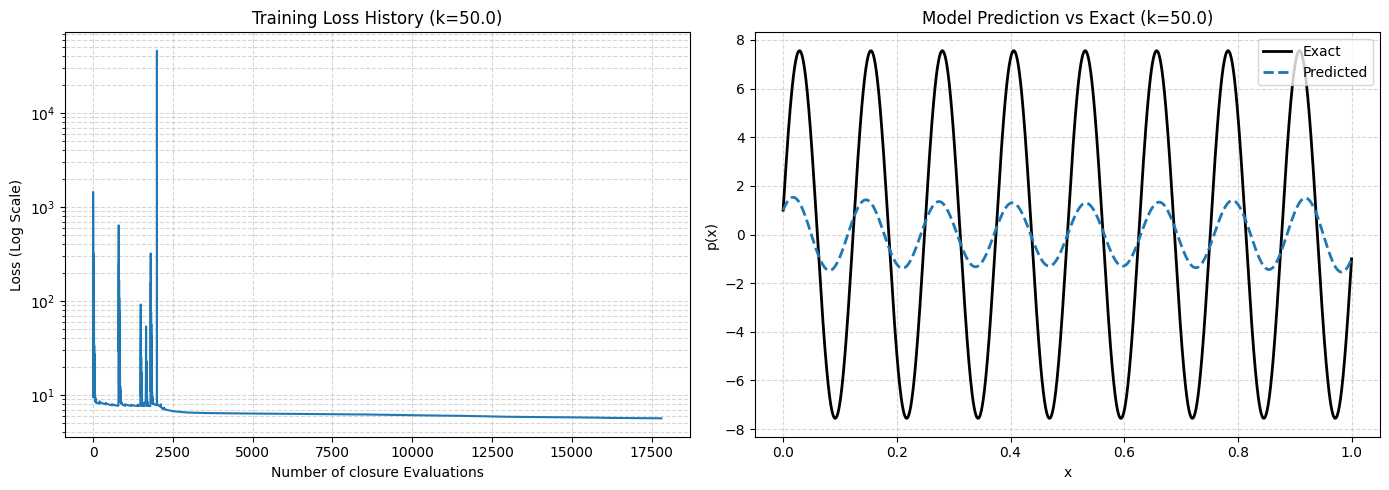

In [16]:
def exact_solution_numpy(x, k):
    denom = np.sin(k)
    denom = denom + 1e-9
    if abs(denom) < 0.1:
        denom = np.sign(denom) * 0.1
        
    c1 = 1.0
    c2 = -(1.0 + np.cos(k)) / denom
    return c1 * np.cos(k * x) + c2 * np.sin(k * x)

i = 0
for k in k_set: 
    with torch.no_grad():
        x_plot = torch.linspace(0, 1, 2000, device=device).view(-1, 1)
        
        pred_eval = models[i](x_plot).cpu().numpy().flatten()
        
        x_eval = x_plot.cpu().numpy().flatten()
        exact_eval = exact_solution_numpy(x_eval, k)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(loss_histories[i])
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Number of closure Evaluations")
    axs[0].set_ylabel("Loss (Log Scale)")
    axs[0].set_title(f"Training Loss History (k={k})")
    axs[0].grid(True, which="both", linestyle="--", alpha=0.5)

    axs[1].plot(x_eval, exact_eval, 'k-', linewidth=2, label="Exact")
    axs[1].plot(x_eval, pred_eval, '--', linewidth=2, label="Predicted")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("p(x)")
    axs[1].set_title(f"Model Prediction vs Exact (k={k})")
    axs[1].grid(True, linestyle="--", alpha=0.5)
    axs[1].legend()

    plt.tight_layout()
    plt.show()
    i += 1

In [17]:
def torch_exact_solution ( x, k ):
    c1 = 1.0
    c2 = - ( 1.0 + np.cos ( k ) ) / np.sin ( k )
    return c1 * torch.cos ( k * x ) + c2 * torch.sin ( k * x )

N_eval = 5000
x_eval = torch.linspace ( 0, 1, N_eval, device = device ).view ( -1, 1 )

for i, k in enumerate ( k_set ):
    current_model = models[i]
    current_model.eval()
    
    with torch.no_grad():
        p_pred = current_model ( x_eval )
        p_true = torch_exact_solution ( x_eval, k )
        
        relative_l2_error =  ( torch.norm ( p_true - p_pred, p = 2 ) / torch.norm ( p_true, p = 2 ) ).item()
        
    print(f"k = {k} - Relative L2 Error: {relative_l2_error}")

k = 10.0 - Relative L2 Error: 6.849317780688849e-05
k = 20.0 - Relative L2 Error: 0.00011508839012161097
k = 30.0 - Relative L2 Error: 0.0004682119894016767
k = 35.0 - Relative L2 Error: 0.0008098471287497673
k = 40.0 - Relative L2 Error: 0.00017146355608636937
k = 42.0 - Relative L2 Error: 0.0003722246015816224
k = 44.0 - Relative L2 Error: 0.9945426755304994
k = 46.0 - Relative L2 Error: 0.0034822654248194322
k = 48.0 - Relative L2 Error: 0.0016134648193246346
k = 50.0 - Relative L2 Error: 0.8284204138696462
